In [49]:
import os
import random
import numpy as np
import cv2
import tensorflow as tf
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Tensorflow versiyonunu yazdır
print("tensorflow version is:", tf.__version__)

tensorflow version is: 2.18.0


In [50]:
xray_data_dir = "../data/chest_xray"
test_folder = os.path.join(xray_data_dir, "test")

In [51]:
model_paths = ["best_model_1.keras", "best_model_2.keras", "best_model_3.keras"]

In [52]:
def load_single_image(image_path, image_size=(256, 256)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Resim okunamadı: {image_path}")
    img = cv2.resize(img, image_size)
    img = np.expand_dims(img, axis=-1)  # kanal boyutunu ekle
    img = img / 255.0  # normalize et
    return img


In [53]:
test_subdirs = [d for d in os.listdir(test_folder) if os.path.isdir(os.path.join(test_folder, d))]
if len(test_subdirs) < 1:
    raise ValueError("Test dizininde alt klasör bulunamadı.")

In [54]:
selected_images = []
selected_labels = []
for subdir in test_subdirs:
    class_dir = os.path.join(test_folder, subdir)
    if subdir.lower() == "normal":
        image_path = os.path.join(class_dir, "NORMAL2-IM-0278-0001.jpeg")
    elif subdir.lower() == "pneumonia":
        image_path = os.path.join(class_dir, "person128_bacteria_606.jpeg")
    else:
        continue
    selected_images.append(image_path)
    selected_labels.append(subdir)

In [55]:
if len(selected_images) > 2:
    selected_images = selected_images[:2]
    selected_labels = selected_labels[:2]

In [56]:
loaded_images = []
for img_path in selected_images:
    loaded_images.append(load_single_image(img_path))

In [57]:
all_predictions = []

In [58]:
for model_path in model_paths:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model dosyası bulunamadı: {model_path}")
    model = tf.keras.models.load_model(model_path)
    print(f"{model_path} yüklendi.")
    
    model_predictions = []
    for idx, image in enumerate(loaded_images):
        # Modelin girdi boyutuna uygun hale getirmek için batch boyutunu ekleyelim
        image_expanded = np.expand_dims(image, axis=0)
        prediction = model.predict(image_expanded)
        predicted_class = "Pneumonia" if prediction[0][0] > 0.5 else "Normal"
        model_predictions.append(predicted_class)
        print(f"Model: {model_path} | Resim: {os.path.basename(selected_images[idx])} | Gerçek: {selected_labels[idx]} | Tahmin: {predicted_class}")
    all_predictions.append(model_predictions)
    print("-" * 40)

best_model_1.keras yüklendi.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Model: best_model_1.keras | Resim: NORMAL2-IM-0278-0001.jpeg | Gerçek: NORMAL | Tahmin: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Model: best_model_1.keras | Resim: person128_bacteria_606.jpeg | Gerçek: PNEUMONIA | Tahmin: Pneumonia
----------------------------------------
best_model_2.keras yüklendi.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Model: best_model_2.keras | Resim: NORMAL2-IM-0278-0001.jpeg | Gerçek: NORMAL | Tahmin: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Model: best_model_2.keras | Resim: person128_bacteria_606.jpeg | Gerçek: PNEUMONIA | Tahmin: Pneumonia
----------------------------------------
best_model_3.keras yüklendi.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Model: best_model_3.keras | Resim: NORMAL2-IM-0278-0001.jpeg | Gerçek: NORMAL | Tahmin: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Model: best_model_3.keras | Resim: person128_bacteria_606.jpeg | Gerçek: PNEUMONIA | Tahmin: Pneumonia
-------

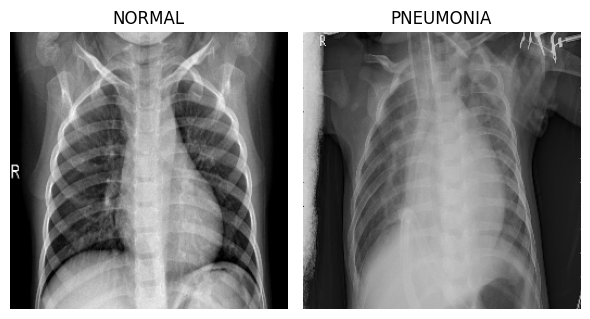

In [60]:
num_images = len(loaded_images)
num_models = len(model_paths)
plt.figure(figsize=(num_models * 2, num_images * 2))

for i in range(num_images):
    plt.subplot(1, num_images, i+1)
    plt.imshow(loaded_images[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"{selected_labels[i]}")
    
plt.tight_layout()
plt.show()